# Импорт библиотек

In [33]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# 1)

In [2]:
df = pd.read_csv('/content/База.csv', sep=';', encoding='cp1251')
df

,УИД_Брони,ДатаБрони,ВремяБрони,ИсточникБрони,ВременнаяБронь,СледующийСтатус,Город,ВидПомещения,Тип,ПродаваемаяПлощадь,...,СтоимостьНаДатуБрони,ТипСтоимости,ВариантОплаты,ВариантОплатыДоп,СкидкаНаКвартиру,ФактическаяСтоимостьПомещения,СделкаАН,ИнвестиционныйПродукт,Привилегия,Статус лида (из CRM)
0,d192173f-fc14-11eb-9512-000c29ad50ac,13.08.2021,1:00:01,ручная,Да,Свободна,Ярославль,жилые помещения,"2,5к",72,...,4296100,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,4296100,Нет,Нет,Нет,S
1,43574a1f-fe8b-11eb-9512-000c29ad50ac,16.08.2021,4:12:46,ручная,Да,Свободна,Ярославль,жилые помещения,"3,5к","79,8",...,5279600,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,5279600,Да,Нет,Нет,F
2,0e7b7a81-fe97-11eb-9512-000c29ad50ac,16.08.2021,5:37:12,ручная,Да,Свободна,Ярославль,жилые помещения,"2,5к","65,4",...,4201400,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,4201400,Нет,Нет,Нет,S
3,c7041428-f90b-11eb-9512-000c29ad50ac,09.08.2021,4:17:35,ручная,Да,Свободна,Тюмень,жилые помещения,"2,5к","61,6",...,5414500,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,5414500,Нет,Нет,Нет,S
4,60090518-fe8b-11eb-9512-000c29ad50ac,16.08.2021,4:13:35,ручная,Да,Свободна,Ярославль,жилые помещения,"2,5к","65,4",...,4201400,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,4201400,Нет,Нет,Нет,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5514,945845a1-6269-11ec-951b-000c29ad50ac,21.12.2021,6:23:36,ручная,Нет,Свободна,Набережные Челны,жилые помещения,с,30,...,2373200,Стоимость при 100% оплате,Единовременная оплата,Ипотека,-94928,2468128,Нет,Нет,Нет,NaN
5515,4f131bfb-78f4-11ec-951d-000c29ad50ac,19.01.2022,10:52:06,ручная,Нет,NaN,Тюмень,кладовые,клад,"3,3",...,124700,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,124700,Нет,Нет,Нет,NaN
5516,74f0e184-78fc-11ec-951d-000c29ad50ac,19.01.2022,11:50:23,МП,Да,Свободна,Набережные Челны,жилые помещения,"1,5к","46,3",...,4499000,Стоимость при 100% оплате,Единовременная оплата,Ипотека,NaN,4499000,Нет,Нет,Нет,NaN
5517,12866ac0-7902-11ec-951d-000c29ad50ac,19.01.2022,12:30:40,МП,Нет,NaN,Пермь,жилые помещения,"2,5к","71,82",...,7422100,Стоимость при 100% оплате,Единовременная оплата,Ипотека,NaN,7422100,Да,Нет,Нет,NaN


# 3)

In [3]:
df_processed = df.copy()

num_cols = ['ПродаваемаяПлощадь', 'Этаж', 'СтоимостьНаДатуБрони', 'СкидкаНаКвартиру', 'ФактическаяСтоимостьПомещения']
for col in num_cols:
  df_processed[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

bin_cols = {'ИсточникБрони': {'ручная': 1, 'МП': 0},
            'ВременнаяБронь': {'Да': 1, 'Нет': 0},
            'ВариантОплаты': {'Единовременная оплата': 1, 'Оплата в рассрочку': 0},
            'ВариантОплатыДоп': {'Ипотека': 1, 'Вторичное жилье': 0},
            'СделкаАН': {'Да': 1, 'Нет': 0},
            'ИнвестиционныйПродукт': {'Да': 1, 'Нет': 0},
            'Привилегия': {'Да': 1, 'Нет': 0},
            'СледующийСтатус': {'Свободна': 0, 'Продана': 1, 'В резерве': 2}}
for col, mapping in bin_cols.items():
  df_processed[col] = df[col].map(mapping)

cat_cols = ['Город', 'ТипСтоимости', 'Статус лида (из CRM)', 'Тип']
df_processed = pd.get_dummies(df_processed, columns=cat_cols)

print("Обработанные данные")
df_processed.dtypes

Обработанные данные


,0
УИД_Брони,object
ДатаБрони,object
ВремяБрони,object
ИсточникБрони,int64
ВременнаяБронь,int64
СледующийСтатус,float64
ВидПомещения,object
ПродаваемаяПлощадь,float64
Этаж,float64
СтоимостьНаДатуБрони,float64


# 2)

In [4]:
df_f = df_processed[df_processed['ВидПомещения'].str.strip() == 'жилые помещения'].copy()
df_f = df_f.drop(['УИД_Брони', 'ВидПомещения', 'ДатаБрони', 'ВремяБрони'], axis=1)

print('Отфильтрованные данные')
display(df_f)

Отфильтрованные данные


,ИсточникБрони,ВременнаяБронь,СледующийСтатус,ПродаваемаяПлощадь,Этаж,СтоимостьНаДатуБрони,ВариантОплаты,ВариантОплатыДоп,СкидкаНаКвартиру,ФактическаяСтоимостьПомещения,...,Тип_кафе,Тип_клад,Тип_кладовая,Тип_кладовые,Тип_маг,Тип_магазин,Тип_офис,Тип_офисные помещения,Тип_паркинг,Тип_с
0,1,1,0.0,72.00,3.0,4296100.0,1.0,NaN,NaN,4296100.0,...,False,False,False,False,False,False,False,False,False,False
1,1,1,0.0,79.80,2.0,5279600.0,1.0,NaN,NaN,5279600.0,...,False,False,False,False,False,False,False,False,False,False
2,1,1,0.0,65.40,18.0,4201400.0,1.0,NaN,NaN,4201400.0,...,False,False,False,False,False,False,False,False,False,False
3,1,1,0.0,61.60,12.0,5414500.0,1.0,NaN,NaN,5414500.0,...,False,False,False,False,False,False,False,False,False,False
4,1,1,0.0,65.40,18.0,4201400.0,1.0,NaN,NaN,4201400.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5513,1,0,NaN,61.70,14.0,6041700.0,1.0,NaN,185117.0,5856583.0,...,False,False,False,False,False,False,False,False,False,False
5514,1,0,0.0,30.00,14.0,2373200.0,1.0,1.0,-94928.0,2468128.0,...,False,False,False,False,False,False,False,False,False,True
5516,0,1,0.0,46.30,9.0,4499000.0,1.0,1.0,NaN,4499000.0,...,False,False,False,False,False,False,False,False,False,False
5517,0,0,NaN,71.82,20.0,7422100.0,1.0,1.0,NaN,7422100.0,...,False,False,False,False,False,False,False,False,False,False


# 4)

In [5]:
df_f.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4105 entries, 0 to 5518
Data columns (total 46 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ИсточникБрони                           4105 non-null   int64  
 1   ВременнаяБронь                          4105 non-null   int64  
 2   СледующийСтатус                         4020 non-null   float64
 3   ПродаваемаяПлощадь                      4060 non-null   float64
 4   Этаж                                    4105 non-null   float64
 5   СтоимостьНаДатуБрони                    4105 non-null   float64
 6   ВариантОплаты                           4102 non-null   float64
 7   ВариантОплатыДоп                        2298 non-null   float64
 8   СкидкаНаКвартиру                        703 non-null    float64
 9   ФактическаяСтоимостьПомещения           4105 non-null   float64
 10  СделкаАН                                4105 non-null   int64  
 

In [6]:
df_f['СкидкаНаКвартиру'] = df_f['СкидкаНаКвартиру'].fillna(0)
df_f['ПродаваемаяПлощадь'] = df_f['ПродаваемаяПлощадь'].fillna(df_f['ПродаваемаяПлощадь'].median())
df_f = df_f.dropna(subset=['СледующийСтатус'])
for col in ['ВариантОплаты', 'ВариантОплатыДоп', 'СледующийСтатус']:
  df_f[col] = df_f[col].fillna(df_f[col].mode()[0])
print("Датафрейм без пропусков:")
display(df_f.info())

Датафрейм без пропусков:
<class 'pandas.core.frame.DataFrame'>
Index: 4020 entries, 0 to 5518
Data columns (total 46 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ИсточникБрони                           4020 non-null   int64  
 1   ВременнаяБронь                          4020 non-null   int64  
 2   СледующийСтатус                         4020 non-null   float64
 3   ПродаваемаяПлощадь                      4020 non-null   float64
 4   Этаж                                    4020 non-null   float64
 5   СтоимостьНаДатуБрони                    4020 non-null   float64
 6   ВариантОплаты                           4020 non-null   float64
 7   ВариантОплатыДоп                        4020 non-null   float64
 8   СкидкаНаКвартиру                        4020 non-null   float64
 9   ФактическаяСтоимостьПомещения           4020 non-null   float64
 10  СделкаАН                                

/tmp/ipython-input-3999451359.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f[col] = df_f[col].fillna(df_f[col].mode()[0])


None

# 5)

In [7]:
df_f = df_f.copy()

df_f['ЦенаЗаКвадратныйМетр'] = df_f['ФактическаяСтоимостьПомещения'] / df_f['ПродаваемаяПлощадь']
price_with_discount = df_f['ФактическаяСтоимостьПомещения'] + df_f['СкидкаНаКвартиру']
df_f['СкидкаВПроцентах'] = (df_f['СкидкаНаКвартиру'] / price_with_discount) * 100

print("Новые колонки:")
display(df_f[['ЦенаЗаКвадратныйМетр', 'СкидкаВПроцентах']])

Новые колонки:


,ЦенаЗаКвадратныйМетр,СкидкаВПроцентах
0,59668.055556,0.0
1,66160.401003,0.0
2,64241.590214,0.0
3,87897.727273,0.0
4,64241.590214,0.0
...,...,...
5507,75141.935484,0.0
5512,87573.580533,0.0
5514,82270.933333,-4.0
5516,97170.626350,0.0


# 6)

In [8]:
num_cols = num_cols + ['ЦенаЗаКвадратныйМетр', 'СкидкаВПроцентах']

scaler = StandardScaler()
df_f[num_cols] = scaler.fit_transform(df_f[num_cols])

print("Числовые колонки после нормализации:")
df_f[num_cols].describe()

Числовые колонки после нормализации:


,ПродаваемаяПлощадь,Этаж,СтоимостьНаДатуБрони,СкидкаНаКвартиру,ФактическаяСтоимостьПомещения,ЦенаЗаКвадратныйМетр,СкидкаВПроцентах
count,4.020000e+03,4.020000e+03,4.020000e+03,4.020000e+03,4.020000e+03,4.020000e+03,4.020000e+03
mean,3.411312e-16,-1.767519e-17,2.969432e-16,-2.121023e-17,3.110834e-16,-6.221668e-16,6.009565e-17
std,1.000124e+00,1.000124e+00,1.000124e+00,1.000124e+00,1.000124e+00,1.000124e+00,1.000124e+00
min,-1.800669e+00,-1.260928e+00,-1.627353e+00,-1.089072e+01,-1.627424e+00,-1.525790e+00,-6.380082e+00
25%,-7.939662e-01,-7.263621e-01,-6.848913e-01,-2.322261e-01,-6.804482e-01,-6.161404e-01,-2.166086e-01
50%,5.954123e-03,-1.917965e-01,-1.909947e-01,-2.322261e-01,-1.964506e-01,-1.986375e-01,-2.166086e-01
75%,5.316160e-01,6.991463e-01,4.798949e-01,-2.322261e-01,4.815540e-01,3.015934e-01,-2.166086e-01
max,4.313008e+00,3.015597e+00,9.538147e+00,1.672594e+01,9.591558e+00,1.279072e+01,1.628222e+01


# 7)

In [9]:
for col, mapping in bin_cols.items():
  print(df_f[col].value_counts(normalize=True))

ИсточникБрони
0    0.631343
1    0.368657
Name: proportion, dtype: float64
ВременнаяБронь
0    0.705224
1    0.294776
Name: proportion, dtype: float64
ВариантОплаты
1.0    0.885323
0.0    0.114677
Name: proportion, dtype: float64
ВариантОплатыДоп
1.0    0.990796
0.0    0.009204
Name: proportion, dtype: float64
СделкаАН
0    0.58408
1    0.41592
Name: proportion, dtype: float64
ИнвестиционныйПродукт
0    0.973383
1    0.026617
Name: proportion, dtype: float64
Привилегия
0    0.978358
1    0.021642
Name: proportion, dtype: float64
СледующийСтатус
0.0    0.697512
1.0    0.283582
2.0    0.018905
Name: proportion, dtype: float64


Вывод: данные в некторых колонках плохо сбалансированы.

# 8)

In [10]:
y = df_f['СледующийСтатус']
X = df_f.drop(['СледующийСтатус'], axis=1)

# 9)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(3216, 47)
(804, 47)


# 10, 11, 12, 13)

In [25]:
def model_test(model, X_train, X_test, y_train, y_test):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  precision_val = precision_score(y_test, y_pred, average='weighted')
  recall_val = recall_score(y_test, y_pred, average='weighted')
  f1_val = f1_score(y_test, y_pred, average='weighted')

  print("Точность модели:")
  print(f'Precision: {precision_val}')
  print(f'Recall: {recall_val}')
  print(f'F1: {f1_val}')

In [13]:
print("Оценка KNeighborsClassifier")
model_test(KNeighborsClassifier(), X_train, X_test, y_train, y_test)
print("\nОценка DecisionTreeClassifier")
model_test(DecisionTreeClassifier(), X_train, X_test, y_train, y_test)

Оценка KNeighborsClassifier
Точность модели:
Precision: 0.8363228680348884
Recall: 0.8470149253731343
F1: 0.8338398936758737

Оценка DecisionTreeClassifier
Точность модели:
Precision: 0.8226847183003899
Recall: 0.8271144278606966
F1: 0.8238988581280475


# 14)

Точность предсказания и полнота обнаружения (F1 score) моделей примерно 82%, что является хорошим результатом.

* Precision - отвечает на вопрос: "Среди всех предсказаныых положительных классов, сколько было действительно положителными".

* Recall - отвечает на вопрос: "Среди всех положительных случаев, сколько действительно оказались положительными".

# 15)

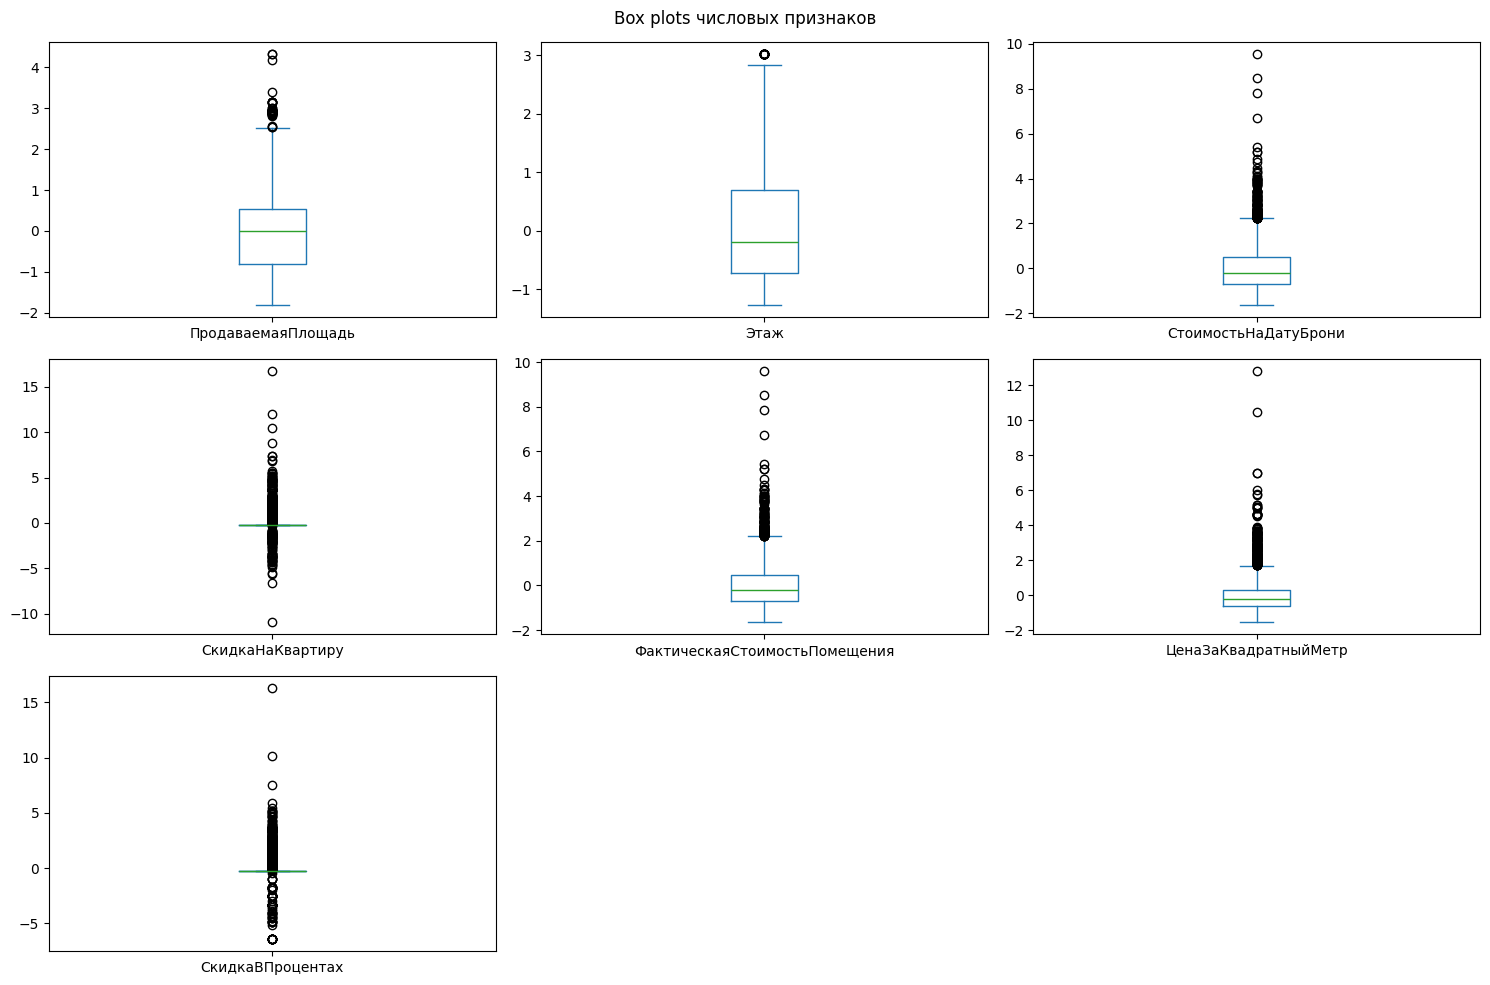

In [18]:
df_f[num_cols].plot(kind='box', subplots=True, layout=(3, 3), figsize=(15, 10))
plt.suptitle('Box plots числовых признаков')
plt.tight_layout()
plt.show()

In [20]:
df_clean = df_f.copy()

for col in num_cols:
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  mask = (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)
  df_clean = df_clean[mask]

y_c = df_clean['СледующийСтатус']
X_c = df_clean.drop(['СледующийСтатус'], axis=1)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

print(X_train_c.shape)
print(X_test_c.shape)

(2415, 47)
(604, 47)


In [22]:
print("Оценка KNeighborsClassifier с датафреймом без выбросов:")
model_test(KNeighborsClassifier(), X_train_c, X_test, y_train_c, y_test)
print("\nОценка DecisionTreeClassifier с датафреймом без выбросов:")
model_test(DecisionTreeClassifier(), X_train_c, X_test, y_train_c, y_test)

Оценка KNeighborsClassifier с датафреймом без выбросов:
Точность модели:
Precision: 0.8009675443932729
Recall: 0.7898009950248757
F1: 0.7577340608675225

Оценка DecisionTreeClassifier с датафреймом без выбросов:
Точность модели:
Precision: 0.8757225895052857
Recall: 0.8718905472636815
F1: 0.8637561097158151


* Модель KNeighbors без выбросов в данных стала хуже предсказывать, примерно на 5-8%.
* Модель DecisionTree без выбросов в данных стала лучше предсказвывать примерно на 3-5%.



# 16)

In [27]:
def model_test_dif_param(model, X_train, X_test, y_train, y_test):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  f1_val = f1_score(y_test, y_pred, average='weighted')

  return f1_val

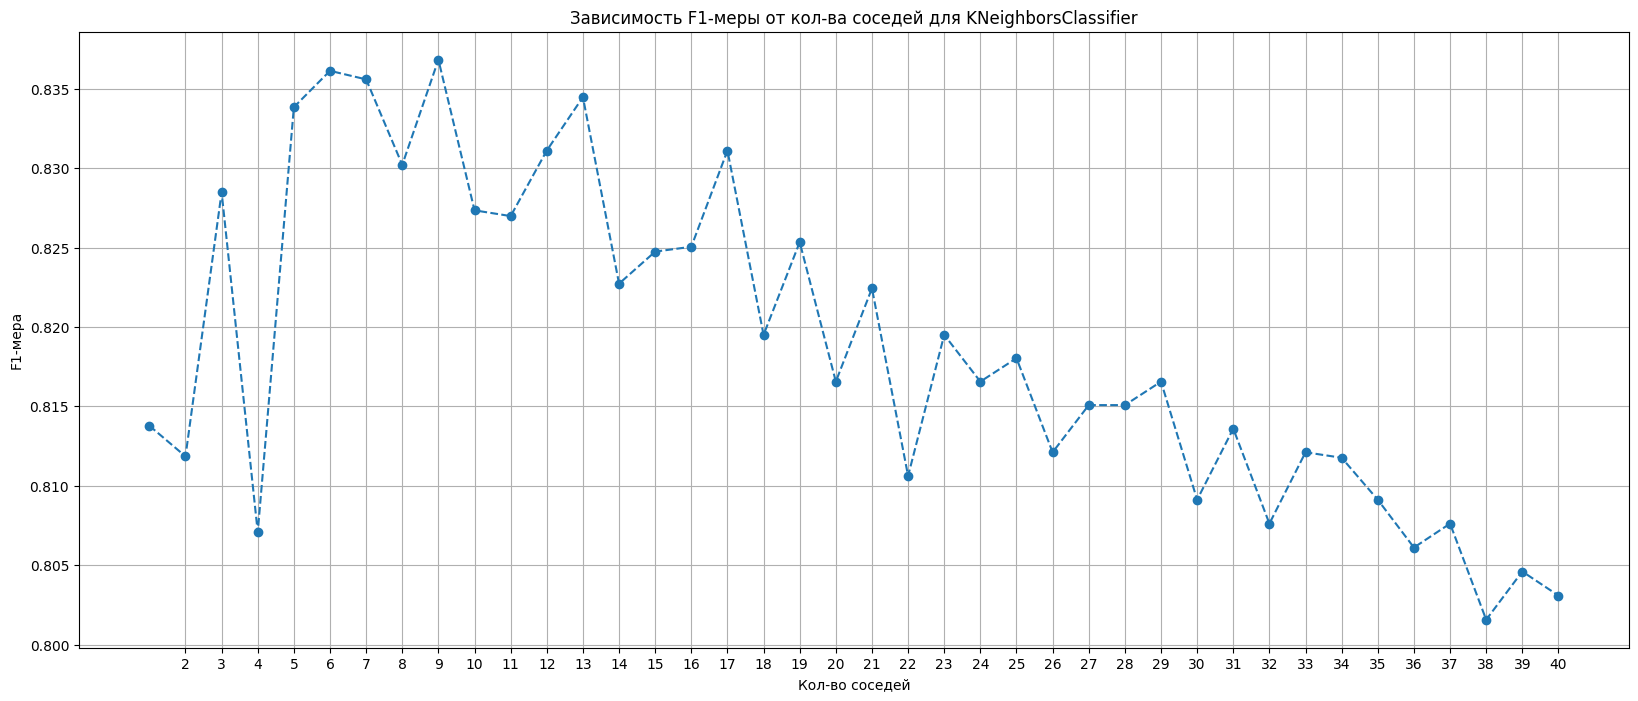

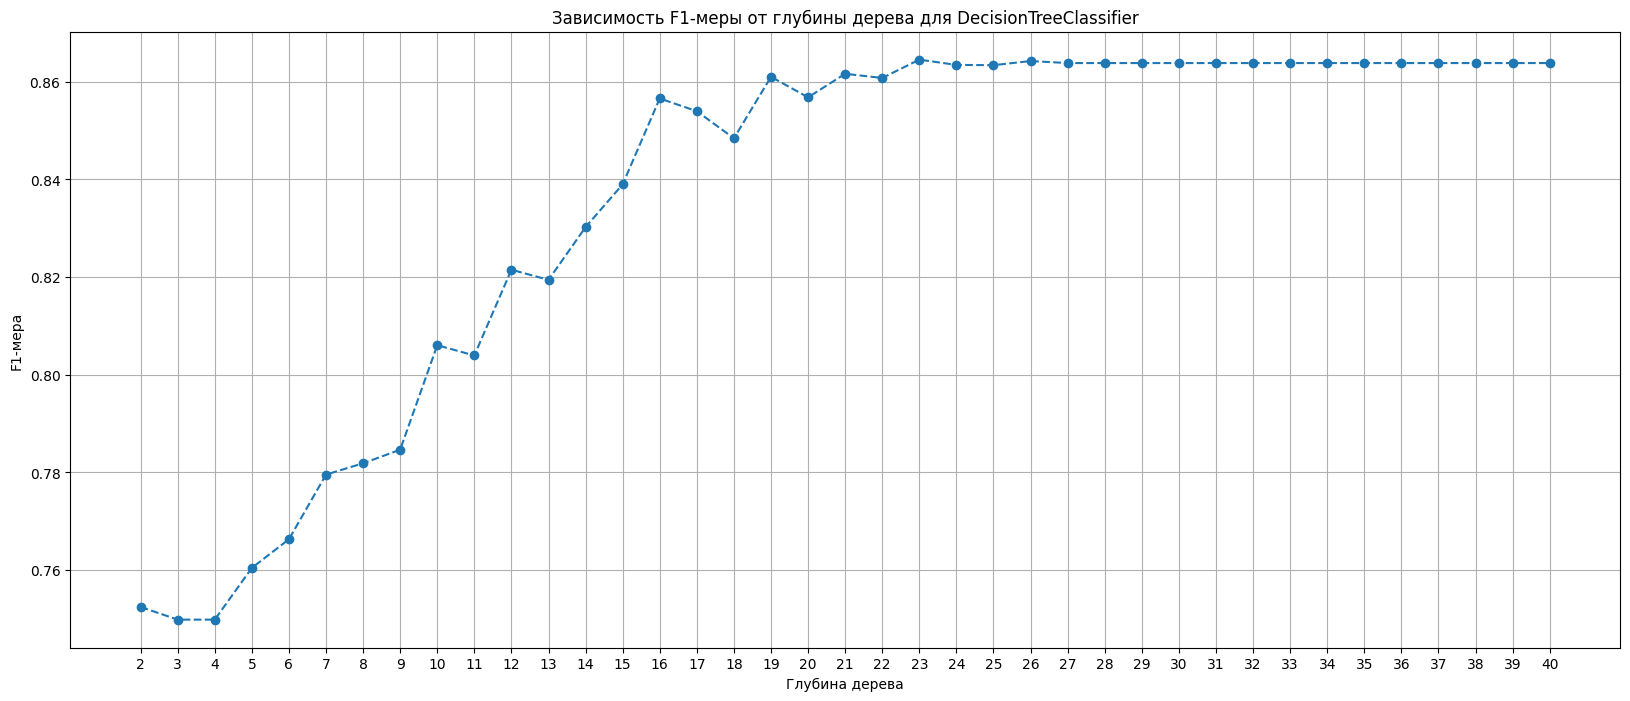

Максимальная оценка для KNeighborsClassifier: 0.8368247741208934
Максимальная оценка для DecisionTreeClassifier: 0.8644948311758769


In [32]:
kn_scores = []
dt_scores = []
k_range = range(1, 41)
depth_range = range(2, 41)

for k in range(1, 41):
  evaluate_kn = model_test_dif_param(KNeighborsClassifier(n_neighbors=k), X_train, X_test, y_train, y_test)
  kn_scores.append(evaluate_kn)

for depth in range(2, 41):
  evaluate_dt = model_test_dif_param(DecisionTreeClassifier(max_depth=depth, random_state=2), X_train_c, X_test, y_train_c, y_test)
  dt_scores.append(evaluate_dt)

plt.figure(figsize=(20, 8))
plt.plot(k_range, kn_scores, marker='o', linestyle='--')
plt.title('Зависимость F1-меры от кол-ва соседей для KNeighborsClassifier')
plt.xlabel('Кол-во соседей')
plt.ylabel('F1-мера')
plt.xticks(depth_range)
plt.grid(True)
plt.show()

plt.figure(figsize=(20, 8))
plt.plot(depth_range, dt_scores, marker='o', linestyle='--')
plt.title('Зависимость F1-меры от глубины дерева для DecisionTreeClassifier')
plt.xlabel('Глубина дерева')
plt.ylabel('F1-мера')
plt.xticks(depth_range)
plt.grid(True)
plt.show()

print(f"Максимальная оценка для KNeighborsClassifier: {max(kn_scores)}")
print(f"Максимальная оценка для DecisionTreeClassifier: {max(dt_scores)}")

# 17)

In [36]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
print("Логистическая регрессия:")
model_test(log_reg, X_train, X_test, y_train, y_test)

Логистическая регрессия:
Точность модели:
Precision: 0.8173069365638004
Recall: 0.8333333333333334
F1: 0.820613957950757


# 18)

In [37]:
svm = LinearSVC(random_state=42)
print("SVM:")
model_test(svm, X_train, X_test, y_train, y_test)

SVM:
Точность модели:
Precision: 0.8409126949522052
Recall: 0.8395522388059702
F1: 0.8249429736976926


Вывод:
* Лучашя модель - это DecisionTree без выбросов с глубиной дерева 40.